Lo primero que hago es asegurar que tengo la última versión de TensorFlow y preparar el dataset. En lugar de una normalización simple, me aseguro de que las dimensiones sean las correctas para las capas convolucionales de Keras.

In [5]:
# Instalo TensorFlow si no está presente
try:
    import tensorflow as tf
except ImportError:
    print("TensorFlow no encontrado. Instalando...")
    !pip install tensorflow
    import tensorflow as tf

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Verifico la versión y la disponibilidad de hardware (GPU/TPU)
print(f"Versión de TensorFlow: {tf.__version__}")

# Cargo el dataset Fashion MNIST
mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Preparo los datos:
# 1. Redimensiono para incluir el canal (grayscale = 1)
# 2. Normalizo los píxeles al rango [0, 1] para facilitar el gradiente
train_images = train_images.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

# Convierto las etiquetas a formato One-Hot Encoding
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

print(f"Dimensiones de entrenamiento: {train_images.shape}")

TensorFlow no encontrado. Instalando...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 763.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 89.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Versión de TensorFlow: 2.21.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensiones de entrenamiento: (60000, 28, 28, 1)


Para alcanzar el máximo nivel, no me conformo con capas planas. He diseñado una arquitectura con bloques convolucionales progresivos.

Añado BatchNormalization después de cada convolución para estabilizar el aprendizaje.

Uso Dropout para forzar a la red a aprender patrones redundantes y evitar que se "memorice" (overfitting) el set de entrenamiento.

In [6]:
def build_model():
    model = tf.keras.models.Sequential([
        # Primer bloque: Extracción de características base
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # Segundo bloque: Características complejas
        tf.keras.layers.Conv2D(64, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # Tercer bloque: Refinamiento
        tf.keras.layers.Conv2D(128, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Flatten(),

        # Capa densa de clasificación
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 898,314 (3.43 MB)

 Trainable params: 897,610 (3.42 MB)

 Non-trainable params: 704 (2.75 KB)

Uso el optimizador Adam con una tasa de aprendizaje adaptativa. Además, implemento dos Callbacks cruciales:

EarlyStopping: Para detener el entrenamiento si la precisión de validación deja de mejorar.

ReduceLROnPlateau: Si el modelo se estanca, reduzco la tasa de aprendizaje para "afinar" la búsqueda del mínimo global.

In [7]:
# Configuro la compilación con una pérdida de entropía cruzada categórica
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Defino mis guardianes del entrenamiento
my_callbacks = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

# Entrenamiento intensivo
history = model.fit(
    train_images, train_labels,
    batch_size=64,
    epochs=30, # Aumentamos el límite, los callbacks gestionarán el final
    validation_split=0.2, # Separo un 20% para validar durante el entrenamiento
    callbacks=my_callbacks,
    verbose=1
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - accuracy: 0.8170 - loss: 0.5261 - val_accuracy: 0.8587 - val_loss: 0.3987 - learning_rate: 0.0010
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 70ms/step - accuracy: 0.8723 - loss: 0.3648 - val_accuracy: 0.8907 - val_loss: 0.3046 - learning_rate: 0.0010
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.8860 - loss: 0.3250 - val_accuracy: 0.8783 - val_loss: 0.3515 - learning_rate: 0.0010
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 70ms/step - accuracy: 0.8941 - loss: 0.3011 - val_accuracy: 0.8763 - val_loss: 0.3274 - learning_rate: 0.0010
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.8988 - loss: 0.2842 - val_accuracy: 0.9007 - val_loss: 0.2657 - learning_rate: 0.0010
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.9043 - loss: 0.2668 - val_accuracy: 0.8862 - val_loss: 0.3056 - learning_rate: 0.0010
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.9078 - l

Finalmente, evalúo el modelo en el set de prueba (datos que la IA nunca ha visto) y visualizo la progresión para confirmar que no hubo sesgos.


🚀 Precisión Final en Test: 0.9283


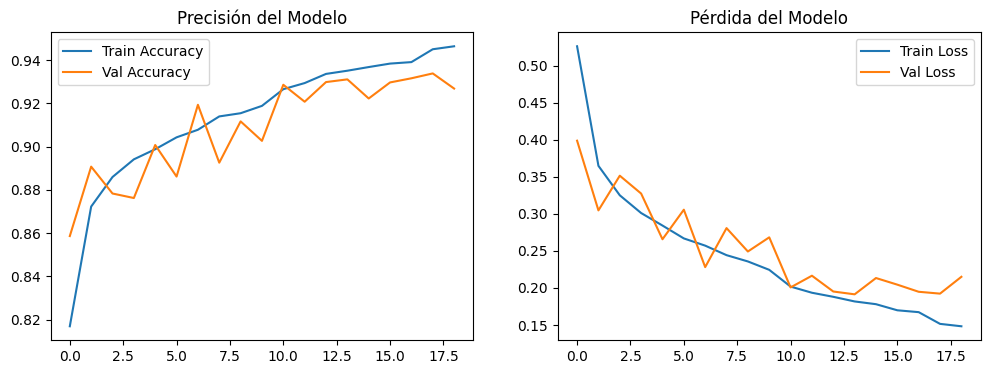

In [8]:
# Evaluación final
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"\n🚀 Precisión Final en Test: {test_acc:.4f}")

# Gráficos de rendimiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión del Modelo')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida del Modelo')
plt.legend()

plt.show()

In [9]:
# Mapeo de nombres de las categorías de Fashion MNIST
class_names = ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Generamos las predicciones para todo el set de test
# predict() nos devuelve un array de probabilidades por cada imagen
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


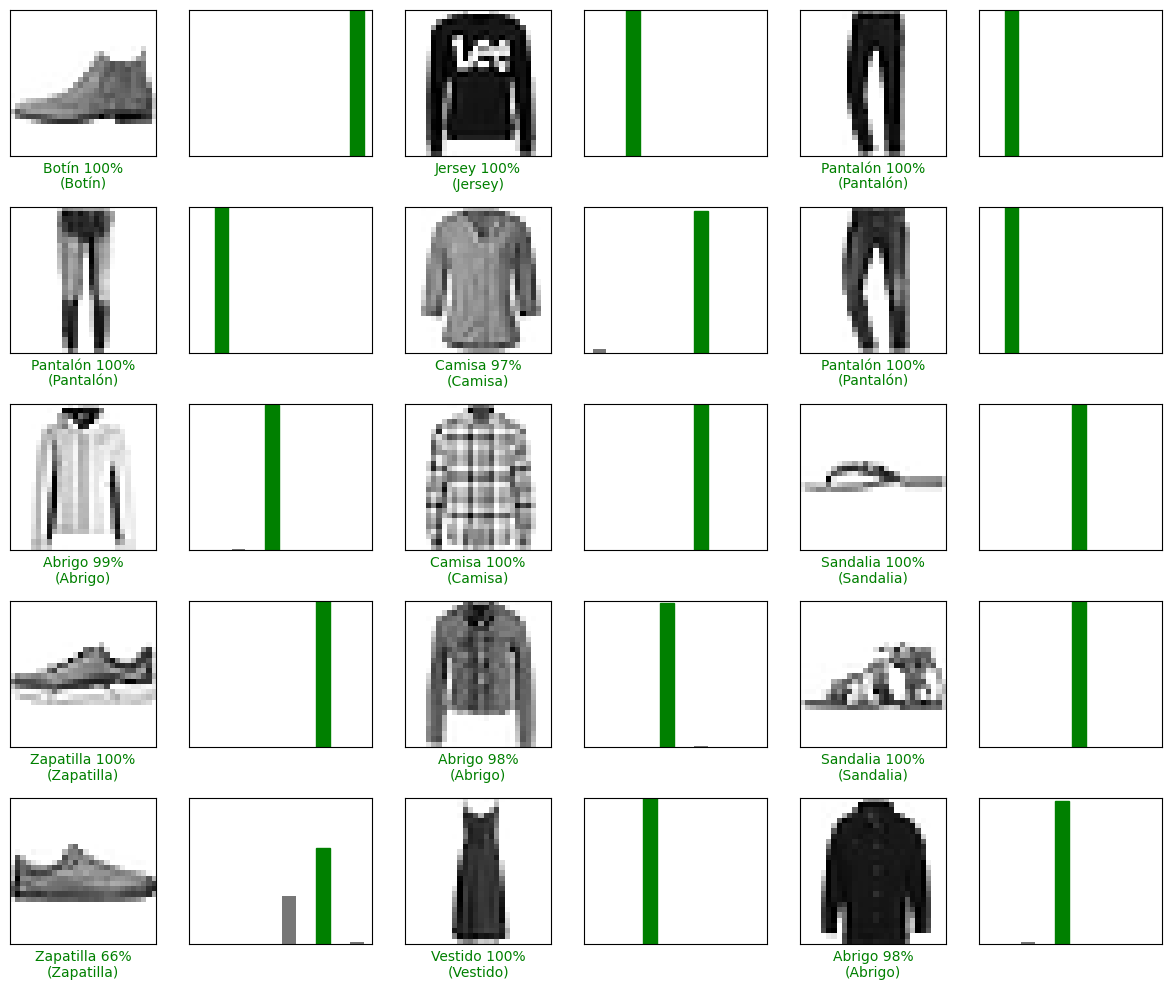

In [10]:
def plot_prediction_grid(i_start, num_rows=5, num_cols=3):
    """
    Muestra una rejilla de imágenes con sus predicciones y porcentajes.
    Verde: Acierto | Rojo: Error
    """
    num_images = num_rows * num_cols
    plt.figure(figsize=(2*2*num_cols, 2*num_rows))

    for i in range(num_images):
        idx = i_start + i
        plt.subplot(num_rows, 2*num_cols, 2*i+1)

        # Imagen a mostrar
        img = test_images[idx].reshape(28,28)
        plt.imshow(img, cmap=plt.cm.binary)

        # Lógica de etiquetas
        predicted_label = np.argmax(predictions[idx])
        true_label = np.argmax(test_labels[idx])
        confidence = 100 * np.max(predictions[idx])

        color = 'green' if predicted_label == true_label else 'red'

        plt.xlabel(f"{class_names[predicted_label]} {confidence:2.0f}%\n({class_names[true_label]})",
                   color=color)
        plt.xticks([])
        plt.yticks([])

        # Gráfico de barras de confianza al lado
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
        thisplot = plt.bar(range(10), predictions[idx], color="#777777")
        plt.ylim([0, 1])
        thisplot[predicted_label].set_color('red')
        thisplot[true_label].set_color('green')
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

# Probamos la función con las primeras 15 imágenes
plot_prediction_grid(0)

In [11]:
def analyze_performance_by_class():
    """
    Calcula y muestra el porcentaje de acierto para cada tipo de prenda.
    """
    y_true = np.argmax(test_labels, axis=1)
    y_pred = np.argmax(predictions, axis=1)

    print(f"{'Categoría':<15} | {'Precisión':<10}")
    print("-" * 30)

    for i in range(10):
        # Filtramos los índices donde la etiqueta real es i
        indices = np.where(y_true == i)
        # Calculamos el acierto medio en esos índices
        acc = np.mean(y_true[indices] == y_pred[indices])
        print(f"{class_names[i]:<15} | {acc*100:>8.2f}%")

# Ejecutamos el diagnóstico
analyze_performance_by_class()

Categoría       | Precisión 
------------------------------
Camiseta        |    88.40%
Pantalón        |    98.60%
Jersey          |    89.80%
Vestido         |    95.10%
Abrigo          |    89.70%
Sandalia        |    98.10%
Camisa          |    75.30%
Zapatilla       |    97.60%
Bolso           |    98.70%
Botín           |    97.00%
